# Panel local projections IV: CPI on xi x oil

This notebook is a notebook-first version of the panel LP-IV workflow.

It mirrors `panel_local_projections.ipynb`, but estimates 2SLS local projections with:

- Endogenous shock: `xi_x_oil`
- Instrument: `xi_x_news`
- Outcome: quarterly CPI inflation (`cpi_pct_change`)


In [29]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent

for path in [ROOT, ROOT / "src"]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import local_projections as lp


In [ ]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
cpi_path = ROOT / "data/processed/cpi/quarterly_cpi.csv"
oil_path = ROOT / "data/processed/oil/quarterly_oil.csv"
news_path = ROOT / "data/processed/oil/kaenzig_oil_supply_surprises_quarterly.csv"
news_column = "news_shock"  # "news_shock" or "surprise"
cpi_freq = "Q"

# Add future controls here. These are merged into the panel.
# Example:
# panel_controls = [
#     {
#         "name": "exchange_rate",
#         "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
#         "value_column": "log_diff",
#         "merge_keys": ["country", "period"],
#         "merge_key_columns": {"country": "country_code", "period": "quarter"},
#         "status_column": None,
#     }
# ]
panel_controls = [
    {
        "name": "exchange_rate",
        "path": ROOT / "data/processed/exchange_rates/quarterly_exchange_rates.csv",
        "value_column": "log_diff",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"country": "country_code", "period": "quarter"},
        "status_column": None,
    },
    {
        "name": "output_gap",
        "path": ROOT / "data/processed/real_gdp/quarterly_output_gap.csv",
        "value_column": "output_gap",
        "merge_keys": ["country", "period"],
        "status_column": "hp_filter_status",
        "ok_status": "ok",
    },
    {
        "name": "policy_rate",
        "path": ROOT / "data/processed/policy_rates/quarterly_policy_rates.csv",
        "value_column": "policy_rate",
        "merge_keys": ["country", "period"],
        "merge_key_columns": {"period": "quarter"},
        "status_column": None,
    }
]

# Controls that actually enter the LP-IV regression.
regression_controls = ["exchange_rate", "output_gap", "policy_rate"]

horizons = 11
y_lags = 3
shock_lags = 3
control_lags = {"exchange_rate": 3, "output_gap": 3, "policy_rate": 3}
include_country_fe = True
include_year_fe = False
cov_type = "cluster_country"
common_sample = True
remove_cpi_outliers = False
iqr_multiplier = 10
exclude_countries = []
sample_start = None
sample_end = None

print("horizons:", horizons)
print("y_lags:", y_lags)
print("shock_lags:", shock_lags)
print("control_lags:", control_lags)
print("include_country_fe:", include_country_fe)
print("include_year_fe:", include_year_fe)
print("cov_type:", cov_type)
print("common_sample:", common_sample)
print("remove_cpi_outliers:", remove_cpi_outliers)
print("iqr_multiplier:", iqr_multiplier)
print("panel_controls:", [spec["name"] for spec in panel_controls])
print("regression_controls:", regression_controls)
print("news_path:", news_path)
print("news_column:", news_column)


horizons: 11
y_lags: 3
shock_lags: 3
control_lags: {'exchange_rate': 3, 'output_gap': 3, 'policy_rate': 3}
include_country_fe: True
include_year_fe: False
cov_type: cluster_country
common_sample: True
remove_cpi_outliers: False
iqr_multiplier: 10
panel_controls: ['exchange_rate', 'output_gap', 'policy_rate']
regression_controls: ['exchange_rate', 'output_gap', 'policy_rate']


In [31]:
panel_df = lp.build_panel_lp_dataset(
    xi_path=xi_path,
    cpi_path=cpi_path,
    oil_path=oil_path,
    news_path=news_path,
    news_column=news_column,
    cpi_freq=cpi_freq,
    controls=panel_controls,
    exclude_countries=exclude_countries,
    sample_start=sample_start,
    sample_end=sample_end,
)

diag_df = lp.panel_diagnostics(panel_df)
diag_df


,rows,countries,year_min,year_max,avg_years_per_country,period_min,period_max,avg_periods_per_country
0,7522,80,1995,2022,23.625,1995-Q1,2022-Q4,94.025


In [32]:
panel_df.head()


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate,output_gap,policy_rate
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.003794,0.171750,0.147258,0.002102,NaN
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.001324,0.209522,0.131988,0.021675,NaN
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000229,0.179419,0.157769,0.062869,NaN
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.005053,0.234092,0.181845,-0.050575,NaN
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.005188,0.200532,0.131072,-0.056534,NaN


In [33]:
panel_df_model = panel_df.copy()

if remove_cpi_outliers:
    q1 = panel_df_model["cpi_pct_change"].quantile(0.25)
    q3 = panel_df_model["cpi_pct_change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - iqr_multiplier * iqr
    upper = q3 + iqr_multiplier * iqr
    panel_df_model = panel_df_model.loc[
        panel_df_model["cpi_pct_change"].between(lower, upper)
    ].copy()
    print(f"CPI IQR fence: [{lower:.6f}, {upper:.6f}]")
    print("Rows after CPI outlier filter:", len(panel_df_model))
    print("Dropped rows:", len(panel_df) - len(panel_df_model))
else:
    print("CPI outlier filter disabled.")
    print("Rows kept:", len(panel_df_model))

panel_df_model.head()


CPI outlier filter disabled.
Rows kept: 7522


,country,year,period,time_index,xi,oil_pct_change,xi_x_oil,cpi_pct_change,exchange_rate,output_gap,policy_rate
0,AGO,2002,2002-Q2,8009,0.019983,0.189848,0.003794,0.171750,0.147258,0.002102,NaN
1,AGO,2002,2002-Q3,8010,0.019983,0.066242,0.001324,0.209522,0.131988,0.021675,NaN
2,AGO,2002,2002-Q4,8011,0.019983,-0.011465,-0.000229,0.179419,0.157769,0.062869,NaN
3,AGO,2003,2003-Q1,8012,0.031061,0.162677,0.005053,0.234092,0.181845,-0.050575,NaN
4,AGO,2003,2003-Q2,8013,0.031061,-0.167036,-0.005188,0.200532,0.131072,-0.056534,NaN


In [34]:
irf_df, coef_df, models = lp.fit_panel_local_projections_iv(
    panel_df_model,
    y_col="cpi_pct_change",
    endog_col="xi_x_oil",
    instrument_col="xi_x_news",
    horizons=horizons,
    y_lags=y_lags,
    shock_lags=shock_lags,
    controls=regression_controls,
    control_lags=control_lags,
    include_country_fe=include_country_fe,
    include_year_fe=include_year_fe,
    cov_type=cov_type,
    common_sample=common_sample,
)

irf_df


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs,n_countries
0,0,xi_x_oil,0.400673,0.043892,9.128657,6.935447e-20,0.314647,0.486699,3538.0,49
1,1,xi_x_oil,0.326296,0.032354,10.085291,6.417474e-24,0.262884,0.389708,3538.0,49
2,2,xi_x_oil,0.048405,0.036923,1.310963,1.898701e-01,-0.023963,0.120773,3538.0,49
3,3,xi_x_oil,0.137323,0.043291,3.172097,1.513422e-03,0.052474,0.222172,3538.0,49
4,4,xi_x_oil,0.110887,0.022945,4.832791,1.346324e-06,0.065916,0.155858,3538.0,49
5,5,xi_x_oil,-0.007999,0.033849,-0.236316,8.131876e-01,-0.074341,0.058343,3538.0,49
6,6,xi_x_oil,-0.014479,0.036628,-0.395308,6.926153e-01,-0.086270,0.057311,3538.0,49
7,7,xi_x_oil,0.075096,0.030584,2.455384,1.407343e-02,0.015152,0.135041,3538.0,49
8,8,xi_x_oil,-0.003856,0.032992,-0.116869,9.069640e-01,-0.068520,0.060808,3538.0,49
9,9,xi_x_oil,-0.047032,0.034760,-1.353036,1.760440e-01,-0.115160,0.021097,3538.0,49


In [35]:
coef_df.loc[coef_df["term"].isin(["xi_x_oil", "xi_x_oil_lag1", "const"])].head(10)


,horizon,term,coef,std_err_cluster_country,t,p_value,ci_low_95,ci_high_95,nobs
0,0,const,0.043884,0.008262,5.311459,1.087512e-07,0.027690,0.060077,3538.0
1,0,xi_x_oil,0.400673,0.043892,9.128657,6.935447e-20,0.314647,0.486699,3538.0
68,1,const,0.047090,0.005989,7.863187,3.744815e-15,0.035352,0.058828,3538.0
69,1,xi_x_oil,0.326296,0.032354,10.085291,6.417474e-24,0.262884,0.389708,3538.0
136,2,const,0.065919,0.008418,7.830337,4.865621e-15,0.049419,0.082419,3538.0
137,2,xi_x_oil,0.048405,0.036923,1.310963,1.898701e-01,-0.023963,0.120773,3538.0
204,3,const,0.058337,0.007767,7.510675,5.882308e-14,0.043114,0.073561,3538.0
205,3,xi_x_oil,0.137323,0.043291,3.172097,1.513422e-03,0.052474,0.222172,3538.0
272,4,const,0.079945,0.010074,7.935648,2.093986e-15,0.060200,0.099690,3538.0
273,4,xi_x_oil,0.110887,0.022945,4.832791,1.346324e-06,0.065916,0.155858,3538.0


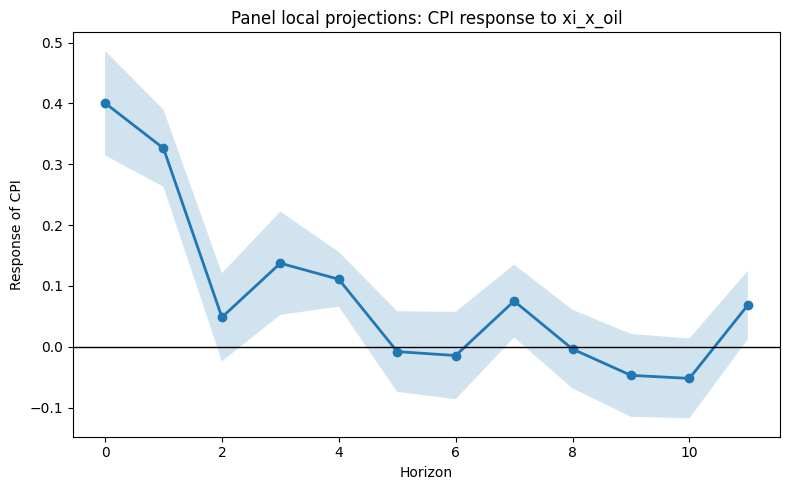

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
lp.plot_irf(irf_df, title="Panel LP-IV: CPI response to xi_x_oil instrumented by xi_x_news", ax=ax)
plt.tight_layout()
plt.show()


In [37]:
horizon_to_inspect = 0
print(models[horizon_to_inspect].summary())


                             OLS Regression Results                             
Dep. Variable:     cpi_pct_change_lead0   R-squared:                       0.545
Model:                              OLS   Adj. R-squared:                  0.536
Method:                   Least Squares   F-statistic:                     159.4
Date:                  Sun, 29 Mar 2026   Prob (F-statistic):           7.71e-37
Time:                          22:09:45   Log-Likelihood:                 12413.
No. Observations:                  3538   AIC:                        -2.469e+04
Df Residuals:                      3470   BIC:                        -2.427e+04
Df Model:                            67                                         
Covariance Type:                cluster                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const         

c:\Users\user\projects\academics\0_diss\analysis\.venv\Lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 67, but rank is 19
  warnings.warn('covariance of constraints does not have full '
